conda create -n sam3 python=3.12
conda deactivate
conda activate sam3

git clone https://github.com/facebookresearch/sam3.git
cd sam3
pip install -e .

Download the checkpoints on the SAM3 hugging face repo

Two interesting notebooks :
https://github.com/facebookresearch/sam3/blob/main/examples/sam3_image_predictor_example.ipynb
https://github.com/facebookresearch/sam3/blob/main/examples/sam3_image_batched_inference.ipynb

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

/usr/users/x_chaos_meteo/arfib_lou/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/usr/users/x_chaos_meteo/arfib_lou/.conda/envs/sam3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [3]:
import os
print(os.uname())

posix.uname_result(sysname='Linux', nodename='sh04', release='5.15.0-78-generic', version='#85-Ubuntu SMP Fri Jul 7 15:25:09 UTC 2023', machine='x86_64')


In [4]:
import torch
print(torch.cuda.is_available())


True


## Build model

In [22]:
# # bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
# model = build_sam3_image_model(bpe_path=bpe_path)
model = build_sam3_image_model()
# image_path = f"{sam3_root}/assets/images/test_image.jpg"
# image_path = '../dataset/altamira/Cueva_de_Altamira-19621007-001.jpg'
image_path = '../dataset/chauvet/panel-of-the-horses-chauvet-cave-replica-6349.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.01)
inference_state = processor.set_image(image)

## Text prompt

found 7 object(s)


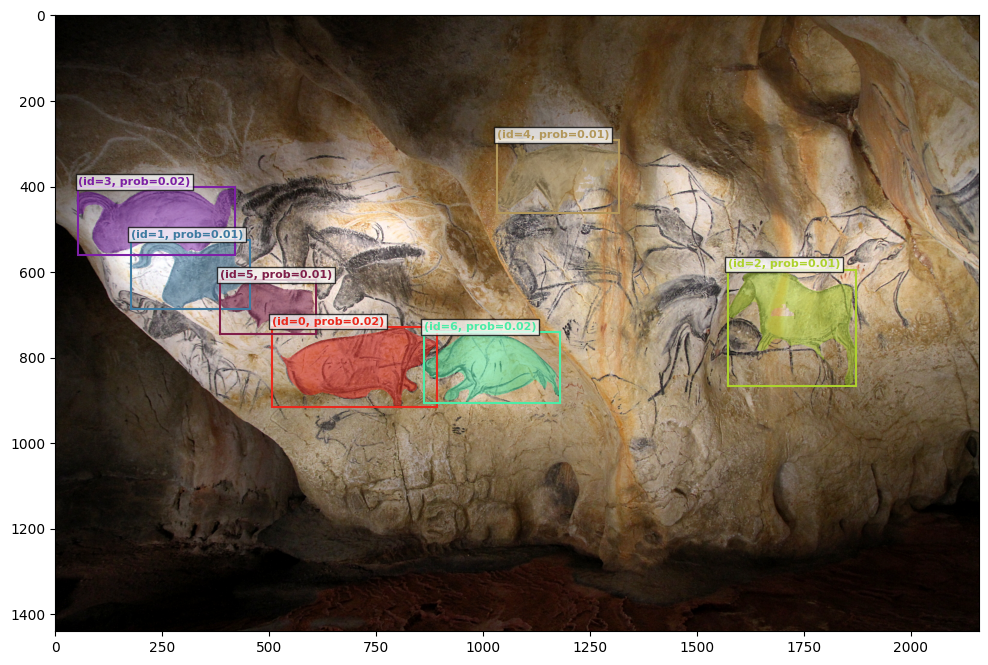

In [26]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="rhinoceros")

masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

In [41]:
# # bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
# model = build_sam3_image_model(bpe_path=bpe_path)
model = build_sam3_image_model()
# image_path = f"{sam3_root}/assets/images/test_image.jpg"
# image_path = '../dataset/altamira/Cueva_de_Altamira-19621007-001.jpg'
image_path = '../dataset/lascaux/Lascaux_020.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.1)
inference_state = processor.set_image(image)

found 15 object(s)


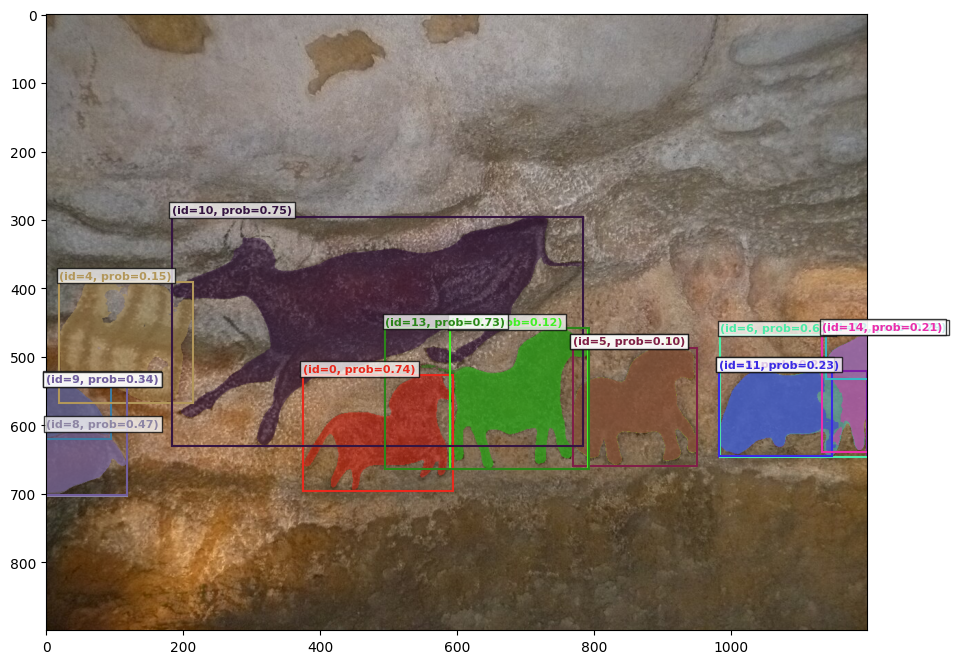

In [50]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="horse")

masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

In [55]:
# # bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
# model = build_sam3_image_model(bpe_path=bpe_path)
model = build_sam3_image_model()
# image_path = f"{sam3_root}/assets/images/test_image.jpg"
image_path = '../dataset/altamira/Cueva_de_Altamira-19621007-001.jpg'
# image_path = '../dataset/lascaux/Lascaux_020.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.01)
inference_state = processor.set_image(image)

found 9 object(s)


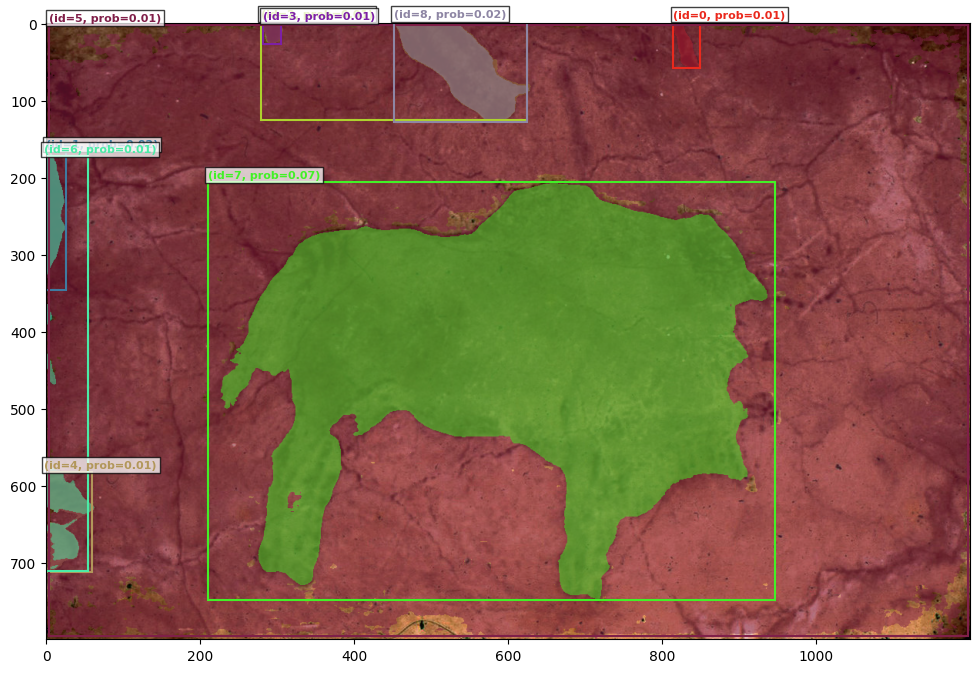

In [56]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="bison")

masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)

In [60]:
# # bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
# model = build_sam3_image_model(bpe_path=bpe_path)
model = build_sam3_image_model()
# image_path = f"{sam3_root}/assets/images/test_image.jpg"
# image_path = '../dataset/altamira/Cueva_de_Altamira-19621007-001.jpg'
image_path = '../dataset/lascaux/Lascaux_001.jpg'
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.1)
inference_state = processor.set_image(image)

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 23.68 GiB of which 17.00 MiB is free. Including non-PyTorch memory, this process has 23.66 GiB memory in use. Of the allocated memory 23.24 GiB is allocated by PyTorch, and 111.50 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="bison")

masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(img0, inference_state)